## Lunar lander with DQN-style neural function approximator using PyTorch
### Christian Igel, 2026

If you have suggestions for improvement, [let me know](mailto:igel@diku.dk).

Imports:

In [2]:
import gymnasium as gym

from tqdm.notebook import tqdm  # Progress bar

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

import time

Define *Q* network architecture:

In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_size=8, action_size=4, hidden_size=10, bias=True):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size, bias)  
        self.fc2 = nn.Linear(hidden_size, hidden_size, bias)  
        self.output_layer = nn.Linear(hidden_size + state_size, action_size, bias)

    def forward(self, x_input):
        x = F.tanh(self.fc1(x_input))
        x = F.tanh(self.fc2(x))
        x = torch.cat((x_input, x), dim=1)
        x = self.output_layer(x)
        return x

Data structure for storing experiences:

In [4]:
class Memory():
    def __init__(self, state_dim, max_size = 1000):
        self.states      = np.zeros([max_size, state_dim], dtype=np.float32)
        self.next_states = np.zeros([max_size, state_dim], dtype=np.float32)
        self.actions     = np.zeros(max_size, dtype=np.int64)
        self.rewards     = np.zeros(max_size, dtype=np.float32)
        self.dones       = np.zeros(max_size, dtype=np.int64)
        self.max_size = max_size
        self.ptr      = 0
        self.size     = 0
    
    def add(self, state, action, reward, next_state, done):
        self.states[self.ptr]      = state
        self.next_states[self.ptr] = next_state
        self.actions[self.ptr]     = action
        self.rewards[self.ptr]     = reward
        self.dones[self.ptr]       = done
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)
        
    def sample_tensors(self, batch_size):
        idxs = np.random.choice(self.size, 
                               size=batch_size, 
                               replace=False)
        return torch.as_tensor(self.states[idxs]), torch.as_tensor(self.actions[idxs]), torch.as_tensor(self.rewards[idxs]), torch.as_tensor(self.next_states[idxs]), torch.as_tensor(self.dones[idxs])
        

Q-learning:

In [5]:
def doit(trial, 
         env,
         state_size,
         action_size,
         double=True,
         train_episodes = 250,           # Max number of episodes to learn from
         gamma = 0.99,                   # Future reward discount
         learning_rate = 0.001,          # Q-network learning rate
         tau = .01,                      # learning rate for target network
         explore_start = 1.0,            # Exploration probability at start
         explore_stop = 0.0001,          # Minimum exploration probability 
         decay_rate = 0.05,              # Exponential decay rate for exploration prob
         hidden_size = 64,               # Number of units in each Q-network hidden layer
         memory_size = 10000,            # Memory capacity
         batch_size = 128,               # Experience mini-batch size
         seed = 41
        ):
    # Return values
    total_rewards = np.zeros(train_episodes)
    
    # Initialize the simulation
    state = env.reset(seed=seed+trial)[0]

    # Experience replay buffer
    memory = Memory(state_dim=state_size, max_size=memory_size)
    
    # Make a bunch of random actions and store the experiences
    pretrain_length = batch_size   # Number experiences to pretrain the memory
    for _ in tqdm(range(pretrain_length)):
        # Make a random action
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Add experience to memory
        memory.add(state, action, reward, next_state, done)

        if done:
            # Start new episode
            env.reset()
            # Take one random step to get the pole and cart moving
            state, reward, terminated, truncated, _ = env.step(env.action_space.sample())
        else:
            state = next_state
    
    # Initialize Q networks
    Q_online = QNetwork(hidden_size=hidden_size)
    Q_target = QNetwork(hidden_size=hidden_size)
    Q_target.load_state_dict(Q_online.state_dict())
    
    # Optimizer and loss
    optimizer = torch.optim.AdamW(Q_online.parameters(), lr=learning_rate) # AdamW uses weight decay by default
    loss_fn = torch.nn.MSELoss(reduction='none')
    
    # Loop over episodes
    for ep in range(train_episodes):
        total_reward = 0  # Return / accumulated rewards
        state = env.reset()[0]  # Reset and get initial state
        while True:
            # Explore or exploit
            explore_p = explore_stop + (explore_start - explore_stop) * np.exp(-decay_rate*ep)
            if explore_p > np.random.rand():
                # Pick a random action
                action = env.action_space.sample()
            else:
                # Get action from Q-network
                with torch.no_grad():
                    state_tensor = torch.as_tensor(state).view(1, -1)
                    Qs = Q_online(state_tensor)
                    action = torch.argmax(Qs).item()
    
            # Take action, get new state and reward
            next_state, reward, terminated, truncated, _ = env.step(action)
            # Both termination and truncation indicate failure 
            done = terminated or truncated

            # Add experience to memory
            memory.add(state, action, reward, next_state, done)
            total_reward += reward  # Return / accumulated rewards
               
            if done:
                print('Episode: {}'.format(ep), 'Total reward: {}'.format(total_reward),
                      'Training loss: {:.4f}'.format(loss), 'Explore P: {:.4f}'.format(explore_p))
                total_rewards[ep] = total_reward
                break; # End of episode
            else:
                state = next_state
                
            # Sample mini-batch from memory
            states, actions, rewards, next_states, dones  = memory.sample_tensors(batch_size)
                  
            # Compute Q values for all actions in the new state       
            target_Qs = Q_target(next_states)
    
            # Transitions to failure state get zero reward
            mask = 1 - dones
    
            # Do (double) Q-learning
            with torch.no_grad():
                q_target_next = Q_target(next_states)
                if(double):
                    q_online_next = Q_online(next_states)
                    argmax_indices = torch.argmax(q_online_next, axis=1, keepdim=True)
                else:
                    argmax_indices = torch.argmax(q_target_next, axis=1, keepdim=True)
                target = q_target_next.gather(1, argmax_indices).squeeze(1).detach() * mask
                # Compute targets
                y = rewards + gamma * target
            
            # Network learning starts here
            optimizer.zero_grad()
            
            # Compute the Q values of the actions taken        
            q_online = Q_online(states)  # Q values for all action in each state
            Q = q_online.gather(1, actions.unsqueeze(-1)).squeeze()  # Only the Q values for the actions taken
            
            # Gradient-based update
            elementwise_loss = loss_fn(Q, y)
            loss = torch.mean(elementwise_loss)
            loss.backward()
            optimizer.step()

            # Update target network
            with torch.no_grad():
                for key, param in Q_online.state_dict().items():
                    Q_target.state_dict()[key].mul_(1 - tau).add_(tau * param)
    return total_rewards

Run experiments:

In [6]:
env = gym.make('LunarLander-v3')
action_size = 4
state_size = 8

no_trials = 10
train_episodes = 250

taus = (0.5,)

start = time.time()
total_rewards_DQN = np.zeros((no_trials, train_episodes))
total_rewards_DDQN = np.zeros((no_trials, train_episodes))
for tau in taus:
    for t in range(no_trials):
        total_rewards_DQN[t] = doit(t, env, state_size, action_size, False, train_episodes = train_episodes, tau=tau, memory_size=8192)
        total_rewards_DDQN[t] = doit(t, env, state_size, action_size, True, train_episodes = train_episodes, tau=tau, memory_size=8192)
    
np.save("DQN_lecture_%d_tau%g.npy" % (no_trials, tau), total_rewards_DQN)
np.save("DDQN_lecture_%d_tau%g.npy" % (no_trials, tau), total_rewards_DDQN)

end = time.time()
print("time: ", end - start)

  0%|          | 0/128 [00:00<?, ?it/s]

Episode: 0 Total reward: -204.34994078354617 Training loss: 85.9076 Explore P: 1.0000
Episode: 1 Total reward: -401.20687585780263 Training loss: 85.0878 Explore P: 0.9512
Episode: 2 Total reward: -13.916875352563821 Training loss: 68.2493 Explore P: 0.9048
Episode: 3 Total reward: -366.74704816808537 Training loss: 120.2315 Explore P: 0.8607
Episode: 4 Total reward: -105.71855044536393 Training loss: 16.0353 Explore P: 0.8187
Episode: 5 Total reward: -137.63728122216457 Training loss: 14.0717 Explore P: 0.7788
Episode: 6 Total reward: -294.4322975661973 Training loss: 9.1445 Explore P: 0.7408
Episode: 7 Total reward: -111.97655386779932 Training loss: 128.8016 Explore P: 0.7047
Episode: 8 Total reward: -203.5850146978537 Training loss: 92.0444 Explore P: 0.6704
Episode: 9 Total reward: -227.9537440076329 Training loss: 29.4178 Explore P: 0.6377
Episode: 10 Total reward: -175.52475719672435 Training loss: 8.8375 Explore P: 0.6066
Episode: 11 Total reward: -63.51841816297292 Training lo

  0%|          | 0/128 [00:00<?, ?it/s]

Episode: 0 Total reward: -138.1540277640806 Training loss: 15.1075 Explore P: 1.0000
Episode: 1 Total reward: -420.5040215163821 Training loss: 140.6474 Explore P: 0.9512
Episode: 2 Total reward: -96.95637998694862 Training loss: 14.9636 Explore P: 0.9048
Episode: 3 Total reward: -169.98387653261057 Training loss: 47.5225 Explore P: 0.8607
Episode: 4 Total reward: -415.09731610241715 Training loss: 12.5507 Explore P: 0.8187
Episode: 5 Total reward: -355.30233483659947 Training loss: 39.8610 Explore P: 0.7788
Episode: 6 Total reward: -110.3574237110553 Training loss: 19.3503 Explore P: 0.7408
Episode: 7 Total reward: -269.01038421890513 Training loss: 10.4610 Explore P: 0.7047
Episode: 8 Total reward: -502.3675893059473 Training loss: 64.3156 Explore P: 0.6704
Episode: 9 Total reward: -214.28694093446282 Training loss: 41.8880 Explore P: 0.6377
Episode: 10 Total reward: -480.4570642667196 Training loss: 16.9056 Explore P: 0.6066
Episode: 11 Total reward: -246.39147807085502 Training los

  0%|          | 0/128 [00:00<?, ?it/s]

...

Episode: 0 Total reward: -115.68643406551303 Training loss: 4.3869 Explore P: 1.0000
Episode: 1 Total reward: -163.9647651463499 Training loss: 2.9551 Explore P: 0.9512
Episode: 2 Total reward: -132.939888148682 Training loss: 52.6634 Explore P: 0.9048
Episode: 3 Total reward: -223.165253048604 Training loss: 49.7482 Explore P: 0.8607
Episode: 4 Total reward: -48.095678121227024 Training loss: 92.1408 Explore P: 0.8187
Episode: 5 Total reward: -125.92226806346952 Training loss: 44.3917 Explore P: 0.7788
Episode: 6 Total reward: -125.38755611884321 Training loss: 78.4862 Explore P: 0.7408
Episode: 7 Total reward: -103.14841365831269 Training loss: 36.7881 Explore P: 0.7047
Episode: 8 Total reward: -25.517764776922235 Training loss: 56.6158 Explore P: 0.6704
Episode: 9 Total reward: -352.1903704161332 Training loss: 122.6067 Explore P: 0.6377
Episode: 10 Total reward: -230.81628742446438 Training loss: 61.2435 Explore P: 0.6066
Episode: 11 Total reward: -159.75303500508707 Training loss:

  0%|          | 0/128 [00:00<?, ?it/s]

Episode: 0 Total reward: -287.0932102356004 Training loss: 58.8729 Explore P: 1.0000
Episode: 1 Total reward: -66.31334256774238 Training loss: 133.3341 Explore P: 0.9512
Episode: 2 Total reward: -426.013882325219 Training loss: 152.3976 Explore P: 0.9048
Episode: 3 Total reward: -151.98743092377424 Training loss: 107.4728 Explore P: 0.8607
Episode: 4 Total reward: -179.6423935941808 Training loss: 5.4902 Explore P: 0.8187
Episode: 5 Total reward: -114.66004838255472 Training loss: 86.9973 Explore P: 0.7788
Episode: 6 Total reward: -214.6062843324522 Training loss: 41.4557 Explore P: 0.7408
Episode: 7 Total reward: -132.4850355418655 Training loss: 130.9489 Explore P: 0.7047
Episode: 8 Total reward: -216.3447542889991 Training loss: 66.8162 Explore P: 0.6704
Episode: 9 Total reward: -113.35195057220204 Training loss: 156.1151 Explore P: 0.6377
Episode: 10 Total reward: -94.20743936178928 Training loss: 64.1601 Explore P: 0.6066
Episode: 11 Total reward: -354.0471762464807 Training loss

  0%|          | 0/128 [00:00<?, ?it/s]

Episode: 0 Total reward: -93.40492785104497 Training loss: 106.3792 Explore P: 1.0000
Episode: 1 Total reward: -378.18175300129775 Training loss: 32.6758 Explore P: 0.9512
Episode: 2 Total reward: -206.60938383223856 Training loss: 3.3146 Explore P: 0.9048
Episode: 3 Total reward: -64.78055262190674 Training loss: 75.3804 Explore P: 0.8607
Episode: 4 Total reward: -149.04563536081383 Training loss: 73.6256 Explore P: 0.8187
Episode: 5 Total reward: -312.45741763543754 Training loss: 148.9092 Explore P: 0.7788
Episode: 6 Total reward: -42.01864857152452 Training loss: 93.2663 Explore P: 0.7408
Episode: 7 Total reward: -51.29144701131594 Training loss: 6.9245 Explore P: 0.7047
Episode: 8 Total reward: -456.5917077238388 Training loss: 8.1912 Explore P: 0.6704
Episode: 9 Total reward: -101.87348973418942 Training loss: 5.1636 Explore P: 0.6377
Episode: 10 Total reward: -94.19248718974575 Training loss: 45.6641 Explore P: 0.6066
Episode: 11 Total reward: -69.26299495845703 Training loss: 2

Make a plot

In [7]:
# Moving average for smoothing plot
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, x[0]*np.ones(N)))
    return (cumsum[N:] - cumsum[:-N]) / N

# Load data and compute percentiles
def compute_stats(filename):
    try:
        data = np.load(filename)
    except:
        print("exception when trying to load ", filename)
    p10 = np.percentile(data, 10, axis=0)
    p50 = np.percentile(data, 50, axis=0)
    p90 = np.percentile(data, 90, axis=0)
    return p10, p50, p90

p10, p50, p90                      = compute_stats("DQN_lecture_%d_tau%g.npy" % (no_trials, tau))
p10_double, p50_double, p90_double = compute_stats("DDQN_lecture_%d_tau%g.npy" % (no_trials, tau))


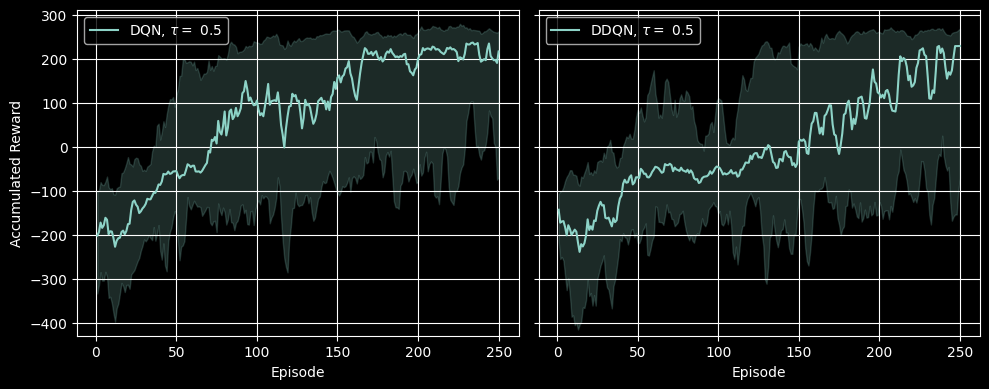

In [12]:
# Smoothing
window = 5
# Create a wide figure and share the y-axis between the two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True);

axes[0].grid(True);
x = np.arange(p50.size) + 1
line, = axes[0].plot(x, running_mean(p50, window), label=rf"DQN, $\tau=$ {tau}")
axes[0].fill_between(x, running_mean(p10, window), running_mean(p90, window), color=line.get_color(), alpha=0.2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Accumulated Reward')
axes[0].legend()

axes[1].grid(True);
x = np.arange(p50_double.size) + 1
line, = axes[1].plot(x, running_mean(p50_double, window), label=rf"DDQN, $\tau=$ {tau}")
axes[1].fill_between(x, running_mean(p10_double, window), running_mean(p90_double, window), color=line.get_color(), alpha=0.2)
axes[1].set_xlabel('Episode')
axes[1].legend()

y_min = min(np.min(m) for m in list(running_mean(p10_double, window)) + list(running_mean(p10, window)))
y_max = max(np.max(m) for m in list(p90) + list(p90_double))
# Add a small margin
pad = 0.02 * (y_max - y_min if y_max > y_min else 1.0)
axes[0].set_ylim(y_min - pad, y_max + pad)


plt.tight_layout()
#plt.show();
plt.savefig('deepQ.png');